# 01 – Data Processing, Feature Engineering & EDA

**Project:** Machine learning based Instagram marketing Strategy  
**Course:** MSDS 696 – Data Practicum II | Regis University

**This notebook covers:**
- Loading and merging the 4 Instagram hashtag datasets
- Data cleaning and null handling
- Feature engineering: `engagement`, `hour`, `time_of_day`, `media_type`
- Exploratory Data Analysis with visualizations (including media type vs engagement)
- Saving the processed dataset as `processed_data.csv` for downstream notebooks

**Output:** `processed_data.csv`  
**Note:** `media_type` (image / carousel / reel) is now retained to enable *what-to-post* recommendations in the RL agent.

## 1. Setup – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
print("Libraries loaded.")

Libraries loaded.


## 2. Load Data

Four CSV files collected from the Instagram API — one per hashtag.  
Each file has: `id`, `media_type`, `timestamp`, `like_count`, `comments_count`, `hashtag`

In [2]:
DATA_FOLDER = "data/"

# Load each file individually so we can verify row counts before merging
df_apple    = pd.read_csv(os.path.join(DATA_FOLDER, "df_apple.csv"))
df_google   = pd.read_csv(os.path.join(DATA_FOLDER, "df_google.csv"))
df_s25      = pd.read_csv(os.path.join(DATA_FOLDER, "df_s25.csv"))
df_s25_edge = pd.read_csv(os.path.join(DATA_FOLDER, "df_s25_edge.csv"))

print("Individual dataset sizes:")
print(f"  #AppleEvent2025  : {len(df_apple):>4} rows")
print(f"  #MadeByGoogle    : {len(df_google):>4} rows")
print(f"  #GalaxyS25       : {len(df_s25):>4} rows")
print(f"  #GalaxyS25Edge   : {len(df_s25_edge):>4} rows")

Individual dataset sizes:
  #AppleEvent2025  : 3064 rows
  #MadeByGoogle    : 3060 rows
  #GalaxyS25       : 5198 rows
  #GalaxyS25Edge   : 5291 rows


In [3]:
# Merge all 4 datasets into one combined DataFrame
df = pd.concat(
    [df_apple, df_google, df_s25, df_s25_edge],
    ignore_index=True
)

# Strip trailing/leading whitespace from hashtag values
# (df_s25 has trailing spaces e.g. "#GalaxyS25  ")
df["hashtag"] = df["hashtag"].str.strip()

print(f"Combined dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")
df.head(8)

Combined dataset: 16613 rows x 6 columns

Column names: ['id', 'media_type', 'timestamp', 'like_count', 'comments_count', 'hashtag']


,id,media_type,timestamp,like_count,comments_count,hashtag
0,22915435894288827_9698230649,image,2025-08-15 15:00:00,449,10,#AppleEvent2025
1,29191953052727066_6956945746,carousel,2025-09-21 09:00:00,371,9,#AppleEvent2025
2,72960122594310041_1245922070,reel,2025-10-04 15:00:00,444,17,#AppleEvent2025
3,05721201179386725_5701477640,carousel,2025-07-26 11:00:00,0,5,#AppleEvent2025
4,53220646887044715_1396570748,carousel,2025-09-02 04:00:00,836,21,#AppleEvent2025
5,27511562278821641_9212565303,reel,2025-09-24 18:00:00,129,4,#AppleEvent2025
6,40744409663510108_2355882897,reel,2025-10-02 13:00:00,854,26,#AppleEvent2025
7,56193423213109339_5413514284,reel,2025-08-31 21:00:00,200,6,#AppleEvent2025


## 3. Data Cleaning

In [4]:
# Check null values before cleaning
print("=== Null Value Check (before cleaning) ===")
print(df.isnull().sum())

# Check unique hashtags (verify all 4 loaded correctly)
print(f"\n=== Unique Hashtags ===")
print(df["hashtag"].value_counts())

=== Null Value Check (before cleaning) ===
id                0
media_type        0
timestamp         0
like_count        0
comments_count    0
hashtag           0
dtype: int64

=== Unique Hashtags ===
hashtag
#GalaxyS25Edge     5291
#GalaxyS25         5198
#AppleEvent2025    3064
#MadeByGoogle      3060
Name: count, dtype: int64


In [5]:
# Parse timestamp — format="mixed" handles both formats present in the data:
#   "2025-08-15 15:00:00"  (apple, google, s25_edge)
#   "12/6/2024 18:00"      (s25)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")

# Drop duplicates (same post id should not appear twice)
before = len(df)
df = df.drop_duplicates(subset=["id"])
print(f"Duplicates removed: {before - len(df)}")

# Drop rows missing essential fields
df = df.dropna(subset=["timestamp", "like_count", "comments_count", "hashtag"])
df = df.reset_index(drop=True)

print(f"Clean dataset: {len(df)} rows")
print(f"\nTimestamp range: {df['timestamp'].min()} → {df['timestamp'].max()}")

Duplicates removed: 0
Clean dataset: 16613 rows

Timestamp range: 2024-11-24 00:00:00 → 2025-10-09 23:00:00


## 4. Feature Engineering

In [6]:
# --- Engagement ---
# Total engagement per post = likes + comments
df["engagement"] = df["like_count"] + df["comments_count"]

# --- Hour ---
# Hour of day (0–23) extracted from timestamp
df["hour"] = df["timestamp"].dt.hour

# --- Time of Day ---
# Bucket hours into 4 named slots for human-readable RL states
def get_time_of_day(hour):
    if 6 <= hour <= 11:
        return "morning"
    elif 12 <= hour <= 17:
        return "afternoon"
    elif 18 <= hour <= 23:
        return "evening"
    else:                   # 0–5
        return "night"

df["time_of_day"] = df["hour"].apply(get_time_of_day)

# --- Day of Week ---
df["day_of_week"] = df["timestamp"].dt.day_name()

# --- Media Type ---
# Standardise to lowercase; fill any missing values with 'unknown'
df["media_type"] = df["media_type"].str.lower().str.strip().fillna("unknown")

print("New columns added: engagement, hour, time_of_day, day_of_week, media_type")
print(f"\nEngagement stats:\n{df['engagement'].describe().round(2)}")
print(f"\nTime-of-day distribution:\n{df['time_of_day'].value_counts()}")
print(f"\nMedia type distribution:\n{df['media_type'].value_counts()}")

New columns added: engagement, hour, time_of_day, day_of_week, media_type

Engagement stats:
count    16613.00
mean       294.43
std        321.70
min          0.00
25%        106.00
50%        204.00
75%        373.00
max      10971.00
Name: engagement, dtype: float64

Time-of-day distribution:
time_of_day
morning      4192
evening      4166
night        4149
afternoon    4106
Name: count, dtype: int64

Media type distribution:
media_type
image       6622
carousel    5867
reel        4124
Name: count, dtype: int64


In [7]:
# Preview the fully engineered dataset
df[["hashtag", "media_type", "timestamp", "like_count", "comments_count",
    "engagement", "hour", "time_of_day", "day_of_week"]].head(10)

,hashtag,media_type,timestamp,like_count,comments_count,engagement,hour,time_of_day,day_of_week
0,#AppleEvent2025,image,2025-08-15 15:00:00,449,10,459,15,afternoon,Friday
1,#AppleEvent2025,carousel,2025-09-21 09:00:00,371,9,380,9,morning,Sunday
2,#AppleEvent2025,reel,2025-10-04 15:00:00,444,17,461,15,afternoon,Saturday
3,#AppleEvent2025,carousel,2025-07-26 11:00:00,0,5,5,11,morning,Saturday
4,#AppleEvent2025,carousel,2025-09-02 04:00:00,836,21,857,4,night,Tuesday
5,#AppleEvent2025,reel,2025-09-24 18:00:00,129,4,133,18,evening,Wednesday
6,#AppleEvent2025,reel,2025-10-02 13:00:00,854,26,880,13,afternoon,Thursday
7,#AppleEvent2025,reel,2025-08-31 21:00:00,200,6,206,21,evening,Sunday
8,#AppleEvent2025,image,2025-10-01 11:00:00,947,31,978,11,morning,Wednesday
9,#AppleEvent2025,reel,2025-09-04 04:00:00,513,12,525,4,night,Thursday


## 5. Exploratory Data Analysis (EDA)

### 5.1 – Engagement Distribution

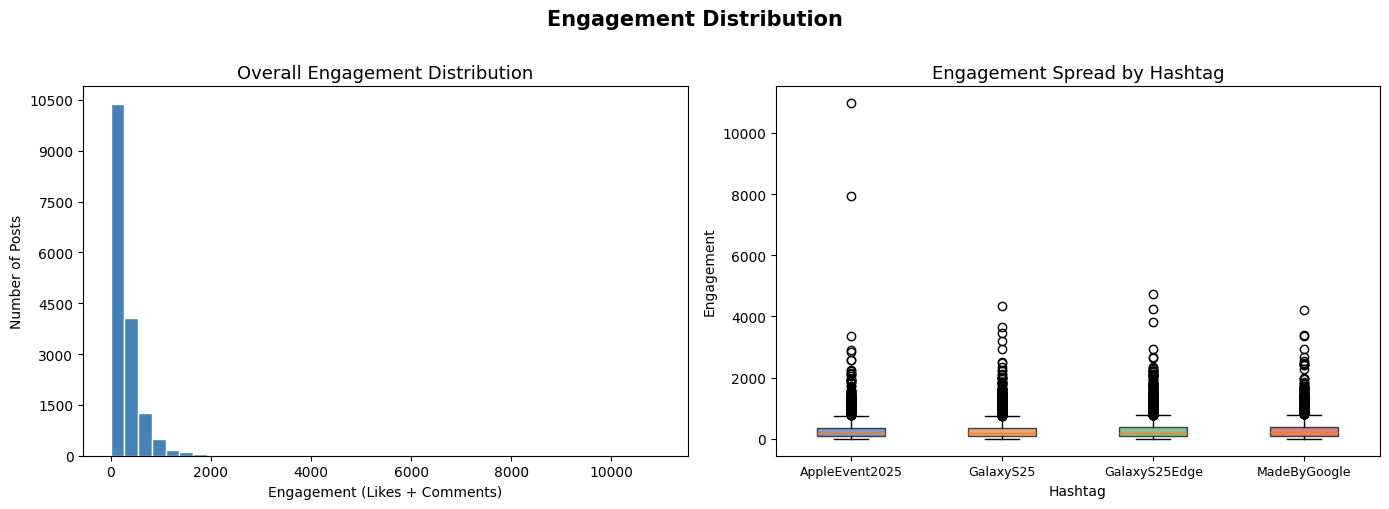

Saved: plot_01_engagement_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of overall engagement
axes[0].hist(df["engagement"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Overall Engagement Distribution", fontsize=13)
axes[0].set_xlabel("Engagement (Likes + Comments)")
axes[0].set_ylabel("Number of Posts")
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: Box plot — engagement spread per hashtag
hashtag_labels = sorted(df["hashtag"].unique())
data_by_hashtag = [df[df["hashtag"] == h]["engagement"].values for h in hashtag_labels]
bp = axes[1].boxplot(data_by_hashtag, patch_artist=True, notch=False)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticks(range(1, len(hashtag_labels) + 1))
axes[1].set_xticklabels([h.replace("#", "") for h in hashtag_labels], fontsize=9)
axes[1].set_title("Engagement Spread by Hashtag", fontsize=13)
axes[1].set_xlabel("Hashtag")
axes[1].set_ylabel("Engagement")

plt.suptitle("Engagement Distribution", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_01_engagement_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_01_engagement_distribution.png")

### 5.2 – Average Engagement by Time of Day & Hashtag

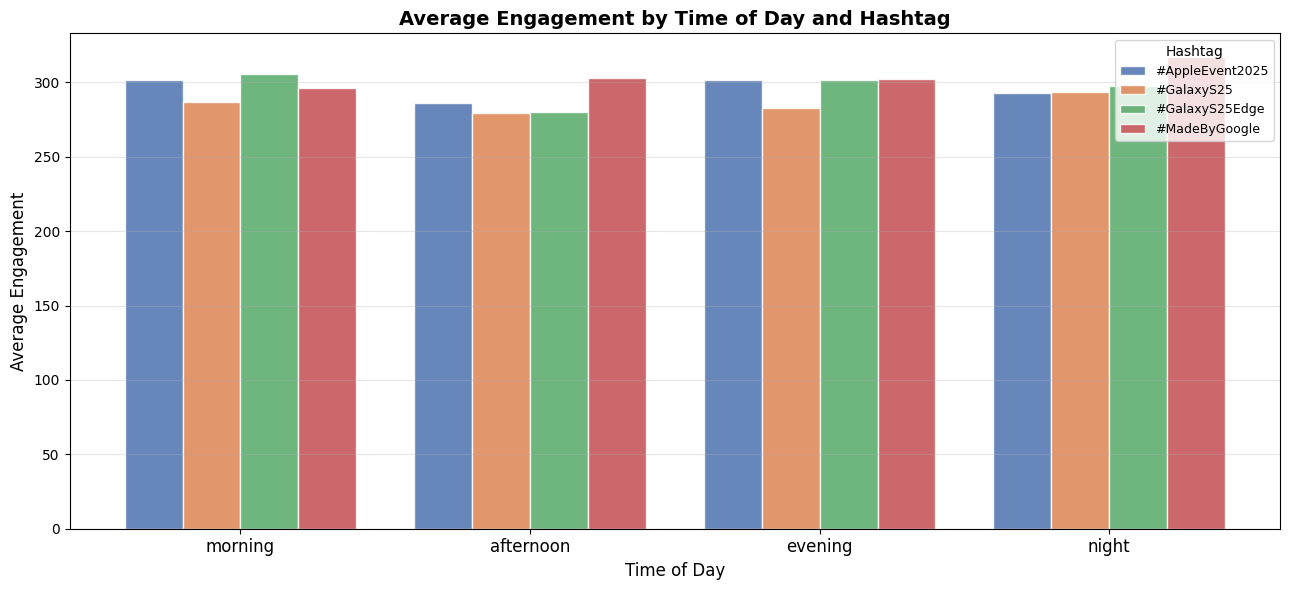

Saved: plot_02_engagement_by_time.png


In [9]:
TIME_ORDER = ["morning", "afternoon", "evening", "night"]
HASHTAG_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

avg_eng = (
    df.groupby(["hashtag", "time_of_day"])["engagement"]
    .mean()
    .reset_index()
)

hashtag_list = sorted(df["hashtag"].unique())
x = np.arange(len(TIME_ORDER))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, (hashtag, color) in enumerate(zip(hashtag_list, HASHTAG_COLORS)):
    subset = avg_eng[avg_eng["hashtag"] == hashtag]
    values = []
    for t in TIME_ORDER:
        match = subset[subset["time_of_day"] == t]["engagement"]
        values.append(match.values[0] if len(match) > 0 else 0)
    ax.bar(x + i * bar_width, values, width=bar_width,
           label=hashtag, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(TIME_ORDER, fontsize=12)
ax.set_title("Average Engagement by Time of Day and Hashtag", fontsize=14, fontweight="bold")
ax.set_xlabel("Time of Day", fontsize=12)
ax.set_ylabel("Average Engagement", fontsize=12)
ax.legend(title="Hashtag", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_02_engagement_by_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_02_engagement_by_time.png")

### 5.3 – Average Engagement by Media Type

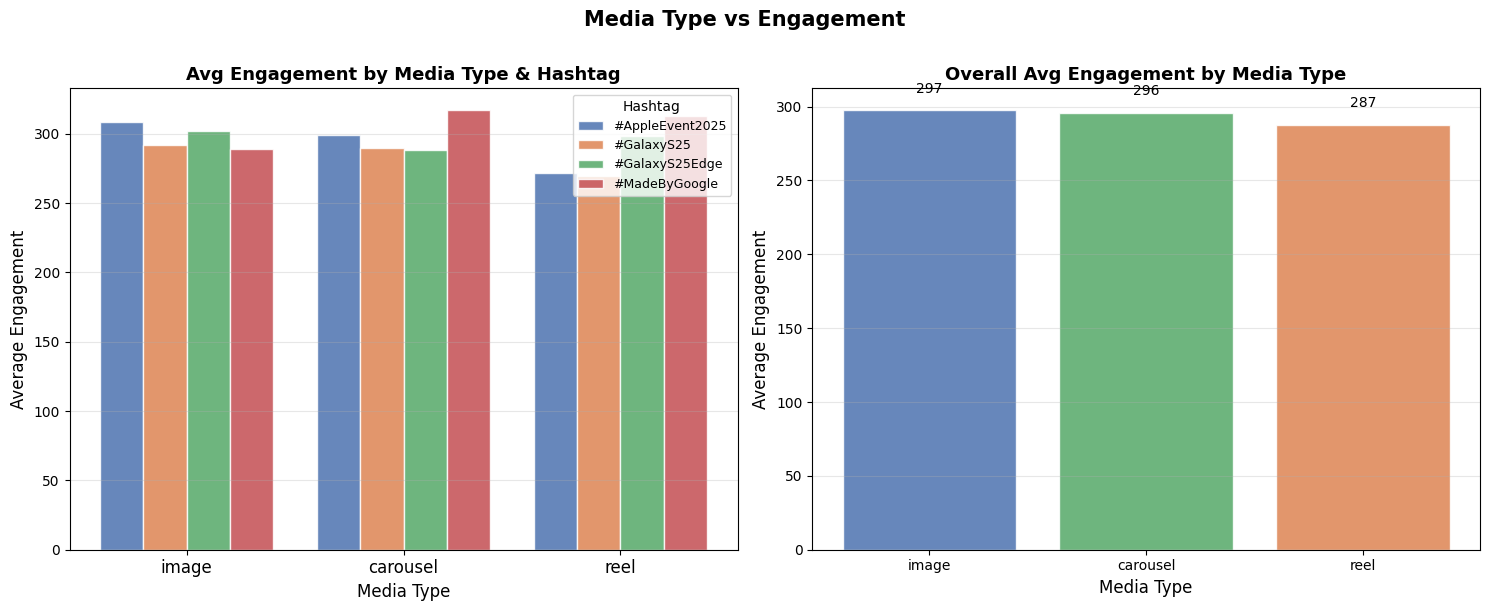

Saved: plot_04_media_type_engagement.png


In [10]:
MEDIA_ORDER  = ["image", "carousel", "reel"]
MEDIA_COLORS = ["#4C72B0", "#55A868", "#DD8452"]

avg_media = (
    df.groupby(["hashtag", "media_type"])["engagement"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: grouped bar – avg engagement per media type per hashtag
x = np.arange(len(MEDIA_ORDER))
bar_width = 0.2
for i, (hashtag, color) in enumerate(zip(hashtag_list, HASHTAG_COLORS)):
    subset = avg_media[avg_media["hashtag"] == hashtag]
    values = []
    for m in MEDIA_ORDER:
        match = subset[subset["media_type"] == m]["engagement"]
        values.append(match.values[0] if len(match) > 0 else 0)
    axes[0].bar(x + i * bar_width, values, width=bar_width,
                label=hashtag, color=color, alpha=0.85, edgecolor="white")

axes[0].set_xticks(x + bar_width * 1.5)
axes[0].set_xticklabels(MEDIA_ORDER, fontsize=12)
axes[0].set_title("Avg Engagement by Media Type & Hashtag", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Media Type", fontsize=12)
axes[0].set_ylabel("Average Engagement", fontsize=12)
axes[0].legend(title="Hashtag", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Right: overall avg engagement by media type (all hashtags combined)
overall_media = df.groupby("media_type")["engagement"].mean().reindex(MEDIA_ORDER)
bars = axes[1].bar(MEDIA_ORDER, overall_media.values, color=MEDIA_COLORS, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, overall_media.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f"{val:.0f}", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Overall Avg Engagement by Media Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Media Type", fontsize=12)
axes[1].set_ylabel("Average Engagement", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Media Type vs Engagement", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_04_media_type_engagement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_04_media_type_engagement.png")

### 5.3 – Hourly Post Volume Heatmap

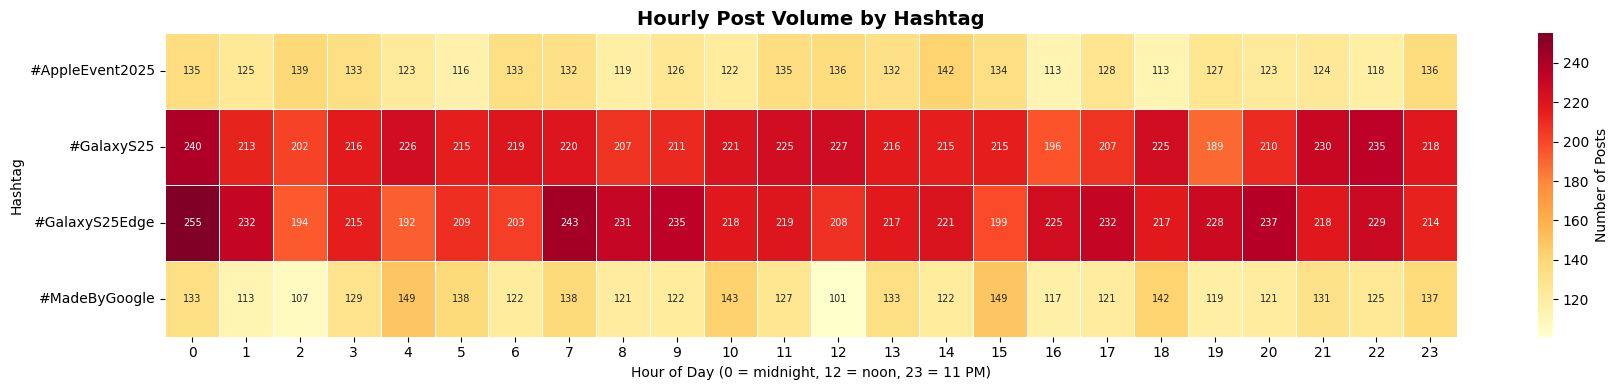

Saved: plot_03_hourly_heatmap.png


In [11]:
# Build pivot table: hashtag × hour → count of posts
pivot = df.groupby(["hashtag", "hour"]).size().unstack(fill_value=0)

# Ensure all 24 hours are represented even if some have 0 posts
pivot = pivot.reindex(columns=range(24), fill_value=0)

plt.figure(figsize=(18, 4))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.4,
    annot=True,
    fmt="d",
    cbar_kws={"label": "Number of Posts"},
    annot_kws={"size": 7}
)
plt.title("Hourly Post Volume by Hashtag", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day (0 = midnight, 12 = noon, 23 = 11 PM)")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.savefig("plot_03_hourly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_03_hourly_heatmap.png")

### 5.4 – Summary Statistics

In [12]:
print("=== Engagement Summary by Hashtag ===")
print(df.groupby("hashtag")["engagement"].describe().round(2))

print("\n=== Mean Engagement by Time of Day (all hashtags combined) ===")
tod_summary = df.groupby("time_of_day")["engagement"].mean().round(2)
tod_summary = tod_summary.reindex(TIME_ORDER)
print(tod_summary)

print("\n=== Mean Engagement by Day of Week ===")
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = df.groupby("day_of_week")["engagement"].mean().round(2)
dow_summary = dow_summary.reindex(DOW_ORDER)
print(dow_summary)

=== Engagement Summary by Hashtag ===
                  count    mean     std  min     25%    50%    75%      max
hashtag                                                                    
#AppleEvent2025  3064.0  295.65  381.74  0.0  104.00  199.0  368.0  10971.0
#GalaxyS25       5198.0  285.74  291.25  0.0  104.00  201.0  367.0   4328.0
#GalaxyS25Edge   5291.0  296.34  311.72  0.0  108.00  206.0  374.0   4722.0
#MadeByGoogle    3060.0  304.68  322.00  0.0  108.75  210.5  386.0   4200.0

=== Mean Engagement by Time of Day (all hashtags combined) ===
time_of_day
morning      297.41
afternoon    285.20
evening      295.72
night        299.27
Name: engagement, dtype: float64

=== Mean Engagement by Day of Week ===
day_of_week
Monday       299.36
Tuesday      308.76
Wednesday    285.87
Thursday     293.18
Friday       291.80
Saturday     282.78
Sunday       298.90
Name: engagement, dtype: float64


## 6. Save Processed Data

Export the cleaned and feature-engineered dataset to `processed_data.csv`.  
This file will be used as the input for all downstream notebooks (`02_clustering`, `03_supervised_model`, `04_rl_agent`).

In [13]:
# Keep only the columns needed by downstream notebooks
# media_type is now included to enable what-to-post recommendations in the RL agent
cols_to_save = [
    "id", "hashtag", "media_type", "timestamp", "like_count", "comments_count",
    "engagement", "hour", "time_of_day", "day_of_week"
]
df[cols_to_save].to_csv("processed_data.csv", index=False)

print(f"Saved: processed_data.csv  ({len(df)} rows, {len(cols_to_save)} columns)")
print("\nColumns saved:")
for c in cols_to_save:
    print(f"  - {c}")

Saved: processed_data.csv  (16613 rows, 10 columns)

Columns saved:
  - id
  - hashtag
  - media_type
  - timestamp
  - like_count
  - comments_count
  - engagement
  - hour
  - time_of_day
  - day_of_week
